# Advanced Persuasion Pattern Analysis for FakeNewsNet Headlines

## Why this problem is difficult

Headlines are:

- short
- noisy
- context-poor
- often implicitly persuasive rather than explicitly argumentative

In short headlines, persuasion is rarely directly observable from a small set of keywords alone. A headline may imply causality, urgency, or authority through syntax, sentence structure, or semantic framing even when no single word is decisive.

## Why simple keyword features are insufficient

Keyword counts can be useful as weak signals, but they are not enough on their own because:

- headlines are highly compressed
- persuasive meaning can be implicit
- structurally similar headlines may use different words
- semantically similar headlines may not overlap lexically

For that reason, we combines:

- **sentence structure**
- **syntactic patterns**
- **semantic embeddings**
- **latent cluster discovery**

## Sentence embeddings

Modern NLP often uses **sentence embeddings**, which convert an entire sentence into a dense vector representation that captures meaning beyond surface words. This allows semantically related headlines to be compared even when they do not share exact vocabulary.

In this notebook, SBERT embeddings are used to model headline meaning at the sentence level. This is especially useful for short persuasive headlines, where overall framing matters more than individual tokens. 

## Persuasion framing used here

The notebook operationalizes three overlapping persuasion blocks:

1. **Central-route features**
   Argumentation-like structure, clause complexity, causal structure, and reasoning cues.

2. **Peripheral-route features**
   Emotion, stylistic emphasis, heuristics, authority cues, and rhetorical shortcuts.

3. **Neutral features**
   More report-like or descriptive cues, with lower emotionality and lower causal intensity.

These are treated as **continuous scores**, not mutually exclusive labels. A headline can simultaneously have central, peripheral, and neutral characteristics in different proportions.

## Main goals

This notebook is designed to:

- discover persuasion patterns beyond surface keywords
- identify which features are present in **more popular fake misinformation**
- discover latent persuasion-style clusters
- build a classifier that helps identify **popular fake misinformation patterns**


## 0. Environment Setup

The next cell checks for the required packages and attempts to install missing ones.

Core packages:

- `pandas`, `numpy`, `matplotlib`, `seaborn`
- `nltk`
- `spacy`
- `sentence-transformers`
- `scikit-learn`
- `umap-learn` (optional, falls back to PCA)
- `xgboost` or `lightgbm` (optional for the classification section)

On first run, the notebook may also download:

- the spaCy English model `en_core_web_sm`
- the SBERT model `all-MiniLM-L6-v2`


In [1]:
from __future__ import annotations

import importlib.util
import subprocess
import sys


def ensure_package(module_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(module_name) is None:
        package_name = pip_name or module_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


REQUIRED = [
    ("numpy", None),
    ("pandas", None),
    ("matplotlib", None),
    ("seaborn", None),
    ("nltk", None),
    ("spacy", None),
    ("sentence_transformers", "sentence-transformers"),
    ("sklearn", "scikit-learn"),
]

OPTIONAL = [
    ("umap", "umap-learn"),
    ("xgboost", None),
    ("lightgbm", None),
]

for module_name, pip_name in REQUIRED:
    ensure_package(module_name, pip_name)

for module_name, pip_name in OPTIONAL:
    try:
        ensure_package(module_name, pip_name)
    except Exception:
        pass

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")

import nltk
for resource in ["vader_lexicon", "punkt"]:
    try:
        nltk.data.find(f"tokenizers/{resource}")
    except LookupError:
        try:
            nltk.data.find(f"sentiment/{resource}.zip")
        except LookupError:
            nltk.download(resource, quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer

import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

from sentence_transformers import SentenceTransformer

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

try:
    from scipy.stats import mannwhitneyu, spearmanr
    SCIPY_AVAILABLE = True
except Exception:
    mannwhitneyu = None
    spearmanr = None
    SCIPY_AVAILABLE = False

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    umap = None
    UMAP_AVAILABLE = False

warnings.filterwarnings("ignore")

DATASET_DIR = Path("FakeNewsNet-master") / "FakeNewsNet-master" / "dataset"
RANDOM_STATE = 42

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATASET_DIR.resolve()}")

print(f"Using dataset directory: {DATASET_DIR.resolve()}")
print(f"UMAP available: {UMAP_AVAILABLE}")



Using dataset directory: C:\Users\Anagha\Desktop\capstone project\Classifier Model\FakeNewsNet-master\FakeNewsNet-master\dataset
UMAP available: True


## 1. Data Loading

We load the four minimal FakeNewsNet manifest files:

- `politifact_fake.csv`
- `politifact_real.csv`
- `gossipcop_fake.csv`
- `gossipcop_real.csv`

Each row contains:

- a headline
- a URL
- tab-separated `tweet_ids`

We add:

- `label` = `fake` or `real`
- `source` = `politifact` or `gossipcop`


In [2]:
FILE_SPECS = [
    ("politifact_fake.csv", "fake", "politifact"),
    ("politifact_real.csv", "real", "politifact"),
    ("gossipcop_fake.csv", "fake", "gossipcop"),
    ("gossipcop_real.csv", "real", "gossipcop"),
]


def load_dataset(dataset_dir: Path) -> pd.DataFrame:
    frames = []
    for filename, label, source in FILE_SPECS:
        path = dataset_dir / filename
        frame = pd.read_csv(path)
        frame["label"] = label
        frame["source"] = source
        if "news_url" in frame.columns:
            frame["url"] = frame["news_url"]
        elif "url" not in frame.columns:
            frame["url"] = np.nan
        frames.append(frame)
    df = pd.concat(frames, ignore_index=True)
    df["label"] = pd.Categorical(df["label"], categories=["fake", "real"])
    df["source"] = pd.Categorical(df["source"], categories=["politifact", "gossipcop"])
    return df


df = load_dataset(DATASET_DIR)
print(f"Shape: {df.shape}")
display(df.head())


Shape: (23196, 7)


,id,news_url,title,tweet_ids,label,source,url
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...,fake,politifact,speedtalk.com/forum/viewtopic.php?t=51650
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...,fake,politifact,politics2020.info/index.php/2018/03/13/court-o...
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...,fake,politifact,www.nscdscamps.org/blog/category/parenting/467...
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...,fake,politifact,https://howafrica.com/oscar-pistorius-attempts...
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...,fake,politifact,http://washingtonsources.org/trump-votes-for-d...


## 2. Data Exploration

Before moving into advanced representations, we inspect:

- dataset size and composition
- headline length
- random examples
- popularity distribution via `tweet_count`


In [3]:
print(f"Total rows: {len(df):,}")
print("\nFake vs real distribution:")
display(df["label"].value_counts().rename_axis("label").to_frame("count"))

print("\nPer-source distribution:")
display(df["source"].value_counts().rename_axis("source").to_frame("count"))

print("\nCross-tab: source x label")
display(pd.crosstab(df["source"], df["label"], margins=True))

df["title"] = df["title"].fillna("").astype(str)
df["raw_word_count"] = df["title"].str.split().str.len()
df["raw_char_count"] = df["title"].str.len()

print("\nRandom headlines:")
display(df["title"].sample(20, random_state=RANDOM_STATE).reset_index(drop=True).to_frame("headline"))

print("\nShortest headlines:")
display(
    df[["title", "label", "source", "raw_word_count", "raw_char_count"]]
    .sort_values(["raw_word_count", "raw_char_count"], ascending=[True, True])
    .head(12)
    .reset_index(drop=True)
)

print("\nLongest headlines:")
display(
    df[["title", "label", "source", "raw_word_count", "raw_char_count"]]
    .sort_values(["raw_word_count", "raw_char_count"], ascending=[False, False])
    .head(12)
    .reset_index(drop=True)
)


Total rows: 23,196

Fake vs real distribution:


,count
label,
real,17441
fake,5755



Per-source distribution:


,count
source,
gossipcop,22140
politifact,1056



Cross-tab: source x label


...

,headline
0,Mariah Carey’s twins steal spotlight at Hollyw...
1,Teen Mom's Most Bombshell and Dramatic Moments
2,S.N.L.: Watch Natalie Portman Rap About Star W...
3,The Arrangement (2017) s02e02 Episode Script
4,The Platinum Life Recap: The Ladies Take a Tri...
5,Hollywood Reacts to Matt Lauer’s Firing: ‘Don’...
6,"Katy Perry, Her ‘Darling’ Orlando Bloom Meet P..."
7,How to Get Smokey Eyes With Makeup
8,The stunning transformation of Miranda Lambert
9,Netflix is dropping two new true crime dramas ...



Shortest headlines:


,title,label,source,raw_word_count,raw_char_count
0,Palin-Huey,real,politifact,1,10
1,john.he.is,real,politifact,1,10
2,VideosTube,fake,gossipcop,1,10
3,Wiktionary,fake,gossipcop,1,10
4,Dailybreak,fake,gossipcop,1,10
5,Shondaland,real,gossipcop,1,10
6,Transcripts,real,politifact,1,11
7,Transcripts,real,politifact,1,11
8,Transcripts,real,politifact,1,11
9,Transcripts,real,politifact,1,11



Longest headlines:


,title,label,source,raw_word_count,raw_char_count
0,or Degrading Treatment of Punishment Text of I...,real,politifact,53,340
1,Mike G.: After high school in the '60s I worke...,real,gossipcop,39,200
2,Actress Sandra Bullock to Hillary Clinton if Y...,fake,politifact,38,200
3,Niall Horan and Hailee Steinfeld Ignite Dating...,real,gossipcop,38,200
4,Laguna Beach Antifa 22m David Hogg Didn't Atte...,fake,politifact,37,200
5,DONALD TRUMP PRAISES COLONEL SANDERS FOR HIS S...,fake,politifact,37,200
6,Singer Tina Turner: “This Thanksgiving Is The ...,fake,politifact,37,200
7,Singer Dolly Parton: “Trump In One Year Is Alr...,fake,politifact,34,200
8,Actress Jennifer Aniston: “Me and All The Trum...,fake,politifact,31,200
9,"Hillary Rodham Clinton, Senator for New York: ...",real,politifact,31,186


### Results: Dataset Composition

The dataset contains **23,196 headlines** drawn from two fact-checking sources:

| Source | Fake | Real | Total |
|--------|------|------|-------|
| GossipCop | 5,323 (24%) | 16,817 (76%) | 22,140 |
| PolitiFact | 432 (41%) | 624 (59%) | 1,056 |

Key observations:

- The dataset is **heavily imbalanced**: real news outnumbers fake by ~3:1 overall.
- GossipCop dominates (~95% of all articles), so patterns are primarily driven by celebrity/entertainment misinformation.
- PolitiFact has a higher fake rate (41%) vs GossipCop (24%), reflecting different editorial standards across domains.
- Shortest headlines (1 word) are mostly page stubs - likely crawling artefacts.
- Longest headlines (up to 53 words) include fabricated celebrity-quote headlines.

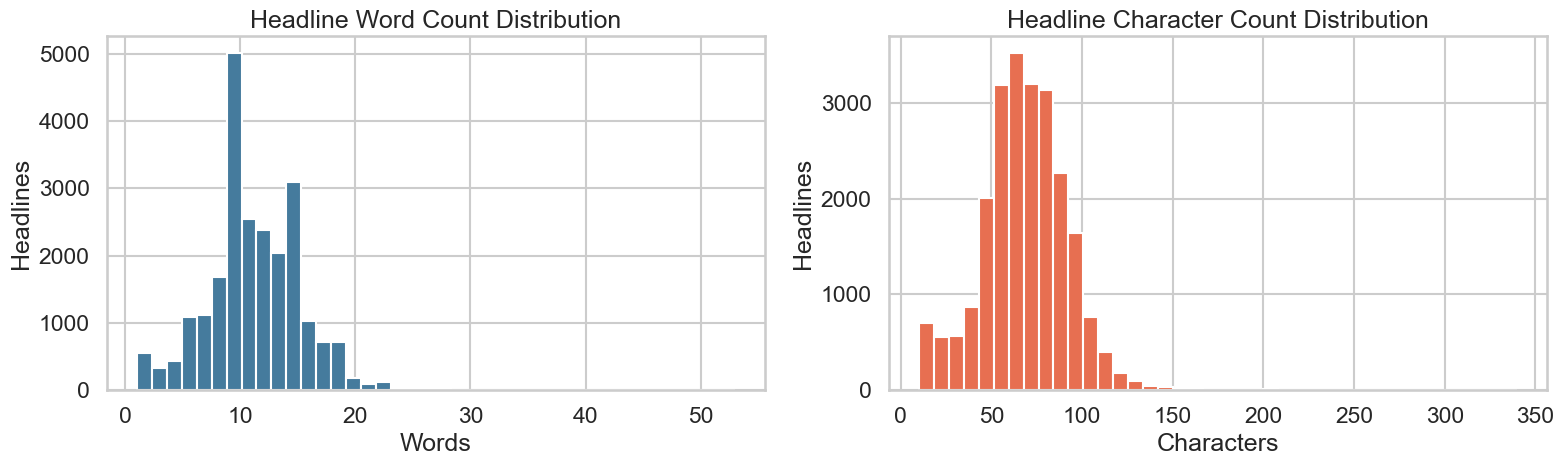

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df["raw_word_count"], bins=40, color="#457b9d", edgecolor="white")
axes[0].set_title("Headline Word Count Distribution")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Headlines")

axes[1].hist(df["raw_char_count"], bins=40, color="#e76f51", edgecolor="white")
axes[1].set_title("Headline Character Count Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Headlines")

plt.tight_layout()
plt.show()


## 3. Preprocessing

We apply light preprocessing that preserves rhetorical and structural cues:

- lowercase
- remove URLs
- normalize whitespace
- keep punctuation
- do not remove stopwords aggressively


### Results: Headline Length Distribution

Most headlines are 5-15 words / 30-80 characters, consistent with the compression typical of news headlines.

The distribution is **right-skewed**: a long tail of unusually verbose headlines exists, mainly from PolitiFact fake news (fabricated celebrity quotes) and some real GossipCop entries.

This matters because short headlines have less syntactic structure so persuasion signals are more implicit and harder to detect with structural features alone.


In [5]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9']+")


def clean_headline(text: str) -> str:
    text = str(text)
    text = URL_PATTERN.sub(" ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_text(text: str) -> list[str]:
    return TOKEN_PATTERN.findall(text)


df["clean_title"] = df["title"].map(clean_headline)
df["tokens"] = df["clean_title"].map(tokenize_text)
display(df[["title", "clean_title", "tokens"]].head())


,title,clean_title,tokens
0,BREAKING: First NFL Team Declares Bankruptcy O...,breaking: first nfl team declares bankruptcy o...,"[breaking, first, nfl, team, declares, bankrup..."
1,Court Orders Obama To Pay $400 Million In Rest...,court orders obama to pay $400 million in rest...,"[court, orders, obama, to, pay, 400, million, ..."
2,UPDATE: Second Roy Moore Accuser Works For Mic...,update: second roy moore accuser works for mic...,"[update, second, roy, moore, accuser, works, f..."
3,Oscar Pistorius Attempts To Commit Suicide,oscar pistorius attempts to commit suicide,"[oscar, pistorius, attempts, to, commit, suicide]"
4,Trump Votes For Death Penalty For Being Gay,trump votes for death penalty for being gay,"[trump, votes, for, death, penalty, for, being..."


## 4. Popularity Metrics

Since the minimal FakeNewsNet release does not include likes, replies, or retweet counts, we derive spread proxies from `tweet_ids`.


In [6]:
def parse_tweet_ids(value: str) -> list[str]:
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [item.strip() for item in text.split("\t") if item.strip()]


df["tweet_id_list"] = df["tweet_ids"].map(parse_tweet_ids)
df["tweet_count"] = df["tweet_id_list"].map(len)
df["log_tweet_count"] = np.log1p(df["tweet_count"])
df["popularity_percentile"] = df["tweet_count"].rank(pct=True, method="average")
viral_threshold = df["tweet_count"].quantile(0.90)
df["viral_flag"] = (df["tweet_count"] >= viral_threshold).astype(int)

display(
    pd.Series(
        {
            "rows": len(df),
            "total_tweet_ids": int(df["tweet_count"].sum()),
            "mean_tweet_count": df["tweet_count"].mean(),
            "median_tweet_count": df["tweet_count"].median(),
            "max_tweet_count": df["tweet_count"].max(),
            "viral_threshold": viral_threshold,
            "viral_share": df["viral_flag"].mean(),
        }
    ).to_frame("value")
)


,value
rows,2.319600e+04
total_tweet_ids,2.063442e+06
mean_tweet_count,8.895680e+01
median_tweet_count,3.700000e+01
max_tweet_count,2.906000e+04
viral_threshold,1.040000e+02
viral_share,1.007070e-01


## 5. Advanced Feature Engineering

This section builds structural, stylistic, semantic, and latent persuasion features rather than relying on simple keyword-only rules.


### 5.1 Structural Features (spaCy)

These features approximate central-route reasoning structure and authority/peripheral cues:

- clause complexity
- dependency relations
- parse depth
- named entities
- discourse markers
- stylistic intensity


### Results: Popularity / Spread Metrics

| Metric | Value |
|--------|-------|
| Total headlines | 23,196 |
| Total tweet IDs | ~2.06 million |
| Mean tweet count | 89 |
| Median tweet count | 37 |
| Max tweet count | 29,060 |
| Viral threshold (top 10%) | 104 tweets |
| Viral share | ~10% of articles |

The distribution is **strongly right-skewed** - median (37) is far below mean (89), and the top 1% of articles are shared orders of magnitude more than the median.

> **Important note**: `tweet_count` is a proxy for spread, not actual virality. It counts collected Twitter IDs, which correlates with but does not directly measure total reach or retweets.


In [8]:
sid = SentimentIntensityAnalyzer()

CONTRAST_MARKERS = {"however", "but", "although", "though", "yet", "while"}
CAUSAL_MARKERS = {"because", "since", "therefore", "thus"}
MODAL_WORDS = {"will", "could", "likely", "may", "might"}
VAGUE_TERMS = {"some", "many", "people", "experts", "sources", "reportedly"}
ABSOLUTIST_WORDS = {"always", "never", "everyone", "nobody", "all", "none"}
REPORTING_VERBS = {"say", "said", "report", "reported", "claim", "claimed", "announce", "announced"}
RHETORICAL_PRONOUNS = {"who", "what", "why", "how", "when"}
EMOTION_LEXICON = {
    "amazing", "angry", "attack", "awful", "crisis", "danger", "dead", "disaster",
    "explosive", "fear", "furious", "incredible", "lies", "outrage", "panic",
    "scandal", "shocking", "stunning", "terrifying", "threat", "warning"
}


def dep_tree_depth(token) -> int:
    children = list(token.children)
    if not children:
        return 1
    return 1 + max(dep_tree_depth(child) for child in children)


def count_svo_patterns(doc) -> int:
    count = 0
    for token in doc:
        if token.pos_ in {"VERB", "AUX"}:
            has_subject = any(child.dep_ in {"nsubj", "nsubjpass", "csubj"} for child in token.children)
            has_object = any(child.dep_ in {"dobj", "obj", "attr", "oprd"} for child in token.children)
            if has_subject and has_object:
                count += 1
    return count


def extract_doc_features(doc) -> dict:
    tokens = [t for t in doc if not t.is_space]
    token_texts = [t.text.lower() for t in tokens]
    n_tokens = len(tokens)
    verb_count = sum(t.pos_ in {"VERB", "AUX"} for t in tokens)
    subordinate_clause_count = sum(t.dep_ in {"advcl", "ccomp", "xcomp", "acl", "relcl"} for t in tokens)
    advcl_count = sum(t.dep_ == "advcl" for t in tokens)
    ccomp_xcomp_count = sum(t.dep_ in {"ccomp", "xcomp"} for t in tokens)
    sentence_length = n_tokens
    clause_count = max(1, verb_count)
    root_verbs = [t.lemma_.lower() for t in tokens if t.dep_ == "ROOT" and t.pos_ in {"VERB", "AUX"}]
    root_verb = root_verbs[0] if root_verbs else ""

    root_tokens = [t for t in tokens if t.dep_ == "ROOT"]
    parse_depth = max((dep_tree_depth(t) for t in root_tokens), default=0)

    person_count = sum(ent.label_ == "PERSON" for ent in doc.ents)
    org_count = sum(ent.label_ == "ORG" for ent in doc.ents)
    entity_count = person_count + org_count

    numbers_per_token = sum(t.like_num for t in tokens) / max(n_tokens, 1)
    contrast_marker_count = sum(tok in CONTRAST_MARKERS for tok in token_texts)
    causal_marker_count = sum(tok in CAUSAL_MARKERS for tok in token_texts)
    modal_count = sum(tok in MODAL_WORDS for tok in token_texts)
    reporting_verb_count = sum(t.lemma_.lower() in REPORTING_VERBS for t in tokens if t.pos_ in {"VERB", "AUX"})

    sentiment_compound = sid.polarity_scores(doc.text)["compound"]
    sentiment_magnitude = abs(sentiment_compound)
    emotion_lexicon_count = sum(tok in EMOTION_LEXICON for tok in token_texts)
    exclamation_count = doc.text.count("!")
    question_count = doc.text.count("?")
    uppercase_word_count = sum(t.text.isupper() and len(t.text) > 1 for t in tokens if t.is_alpha)
    punctuation_density = sum(t.is_punct for t in tokens) / max(n_tokens, 1)
    rhetorical_question = int(question_count > 0 and any(tok in RHETORICAL_PRONOUNS for tok in token_texts))
    vague_term_count = sum(tok in VAGUE_TERMS for tok in token_texts)
    absolutist_count = sum(tok in ABSOLUTIST_WORDS for tok in token_texts)

    return {
        "sentence_length": sentence_length,
        "clause_count": clause_count,
        "verb_count": verb_count,
        "subordinate_clause_count": subordinate_clause_count,
        "advcl_count": advcl_count,
        "ccomp_xcomp_count": ccomp_xcomp_count,
        "svo_pattern_count": count_svo_patterns(doc),
        "root_verb": root_verb,
        "parse_depth": parse_depth,
        "person_count": person_count,
        "org_count": org_count,
        "entity_count": entity_count,
        "numbers_per_token": numbers_per_token,
        "contrast_marker_count": contrast_marker_count,
        "causal_marker_count": causal_marker_count,
        "modal_count": modal_count,
        "reporting_verb_count": reporting_verb_count,
        "sentiment_compound": sentiment_compound,
        "sentiment_magnitude": sentiment_magnitude,
        "emotion_lexicon_count": emotion_lexicon_count,
        "exclamation_count": exclamation_count,
        "question_count": question_count,
        "uppercase_word_count": uppercase_word_count,
        "punctuation_density": punctuation_density,
        "rhetorical_question": rhetorical_question,
        "vague_term_count": vague_term_count,
        "absolutist_count": absolutist_count,
    }


import gc

def process_in_chunks(texts, chunk_size=500):
    results = []
    for i in range(0, len(texts), chunk_size):
        chunk = texts[i:i + chunk_size]
        docs = nlp.pipe(chunk, batch_size=32)
        results.extend([extract_doc_features(doc) for doc in docs])
        gc.collect()
    return results

structural_features = process_in_chunks(df["clean_title"].tolist(), chunk_size=500)
structural_df = pd.DataFrame(structural_features)
df = pd.concat([df.reset_index(drop=True), structural_df.reset_index(drop=True)], axis=1)

display(df.head())


,id,news_url,title,tweet_ids,label,source,url,raw_word_count,raw_char_count,clean_title,...,sentiment_compound,sentiment_magnitude,emotion_lexicon_count,exclamation_count,question_count,uppercase_word_count,punctuation_density,rhetorical_question,vague_term_count,absolutist_count
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy O...,937349434668498944\t937379378006282240\t937380...,fake,politifact,speedtalk.com/forum/viewtopic.php?t=51650,9,64,breaking: first nfl team declares bankruptcy o...,...,0.0000,0.0000,0,0,0,0,0.100000,0,0,0
1,politifact15156,politics2020.info/index.php/2018/03/13/court-o...,Court Orders Obama To Pay $400 Million In Rest...,972666281441878016\t972678396575559680\t972827...,fake,politifact,politics2020.info/index.php/2018/03/13/court-o...,9,53,court orders obama to pay $400 million in rest...,...,-0.1027,0.1027,0,0,0,0,0.000000,0,0,0
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467...,UPDATE: Second Roy Moore Accuser Works For Mic...,929405740732870656\t929439450400264192\t929439...,fake,politifact,www.nscdscamps.org/blog/category/parenting/467...,12,69,update: second roy moore accuser works for mic...,...,0.0000,0.0000,0,0,0,0,0.153846,0,0,0
3,politifact14355,https://howafrica.com/oscar-pistorius-attempts...,Oscar Pistorius Attempts To Commit Suicide,886941526458347521\t887011300278194176\t887023...,fake,politifact,https://howafrica.com/oscar-pistorius-attempts...,6,42,oscar pistorius attempts to commit suicide,...,-0.5106,0.5106,0,0,0,0,0.000000,0,0,0
4,politifact15371,http://washingtonsources.org/trump-votes-for-d...,Trump Votes For Death Penalty For Being Gay,915205698212040704\t915242076681506816\t915249...,fake,politifact,http://washingtonsources.org/trump-votes-for-d...,8,43,trump votes for death penalty for being gay,...,-0.7845,0.7845,0,0,0,0,0.000000,0,0,0


### 5.2 Continuous Central / Peripheral / Neutral Scores

These block scores are continuous and overlapping rather than mutually exclusive.


In [11]:
def minmax(series: pd.Series) -> pd.Series:
    # ensure it's a 1D series (in case of duplicate columns)
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    s_min = float(series.min())
    s_max = float(series.max())
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)

df = pd.concat([df.reset_index(drop=True), structural_df.reset_index(drop=True)], axis=1)

# check and remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]


norm_verb = minmax(df["verb_count"])
norm_subord = minmax(df["subordinate_clause_count"])
norm_advcl = minmax(df["advcl_count"])
norm_ccomp = minmax(df["ccomp_xcomp_count"])
norm_contrast = minmax(df["contrast_marker_count"])
norm_causal = minmax(df["causal_marker_count"] + df["modal_count"])
norm_numeric = minmax(df["numbers_per_token"])
norm_depth = minmax(df["parse_depth"])
norm_entity = minmax(df["entity_count"])
norm_report = minmax(df["reporting_verb_count"])

norm_sent_mag = minmax(df["sentiment_magnitude"])
norm_emotion_lex = minmax(df["emotion_lexicon_count"])
norm_exclaim = minmax(df["exclamation_count"])
norm_question = minmax(df["question_count"])
norm_caps = minmax(df["uppercase_word_count"])
norm_punct = minmax(df["punctuation_density"])
norm_rhet_q = minmax(df["rhetorical_question"])
norm_vague = minmax(df["vague_term_count"])
norm_abs = minmax(df["absolutist_count"])

df["central_score"] = (
    norm_verb + norm_subord + norm_advcl + norm_ccomp + norm_contrast + norm_causal + norm_numeric + norm_depth
) / 8.0

df["peripheral_score"] = (
    norm_sent_mag + norm_emotion_lex + norm_exclaim + norm_question + norm_caps + norm_punct + norm_rhet_q + norm_vague + norm_abs + norm_entity
) / 10.0

df["neutral_score"] = (
    (1 - norm_sent_mag) + (1 - norm_causal) + norm_entity + norm_numeric + norm_report
) / 5.0

df["sentiment_x_length"] = df["sentiment_magnitude"] * df["sentence_length"]
df["caps_x_exclamation"] = df["uppercase_word_count"] * df["exclamation_count"]
df["entity_x_sentiment"] = df["entity_count"] * df["sentiment_magnitude"]
df["central_x_peripheral"] = df["central_score"] * df["peripheral_score"]

display(
    df[
        [
            "central_score",
            "peripheral_score",
            "neutral_score",
            "sentiment_x_length",
            "caps_x_exclamation",
            "entity_x_sentiment",
            "central_x_peripheral",
        ]
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
central_score,23196.0,0.083490,0.054933,0.000000,0.042614,0.067614,0.115341,0.452244
peripheral_score,23196.0,0.070134,0.044929,0.000000,0.038301,0.065694,0.097091,0.358865
neutral_score,23196.0,0.391294,0.071265,0.134876,0.338576,0.400000,0.440000,0.680000
sentiment_x_length,23196.0,3.683511,4.316808,0.000000,0.000000,2.411400,6.369000,50.827000
caps_x_exclamation,23196.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
entity_x_sentiment,23196.0,0.228759,0.369749,0.000000,0.000000,0.000000,0.419900,2.907600
central_x_peripheral,23196.0,0.006240,0.006460,0.000000,0.001976,0.004316,0.008353,0.098163


### 5.3 Semantic Features (SBERT)

SBERT captures sentence-level meaning beyond exact lexical overlap.


In [12]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = sbert_model.encode(
    df["clean_title"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
print(f"Embedding shape: {embeddings.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/182 [00:00<?, ?it/s]

Embedding shape: (23196, 384)


### 5.4 Combined Feature Space

We concatenate structural, stylistic, persuasion-block, interaction, and semantic representations.


### Results: Persuasion Block Scores

**Central score** (argumentation structure): Mean ≈ 0.083. Most headlines score very low - short headlines rarely contain full argumentative syntax.

**Peripheral score** (emotional/stylistic cues): Mean ≈ 0.070. `caps_x_exclamation` is zero for the entire dataset - no headline simultaneously has uppercase words AND exclamation marks, ruling out classic clickbait as a dominant pattern.

**Neutral score** (report-like framing): Mean ≈ 0.39, significantly higher than the others. Most headlines ,real and fake alike, adopt a neutral, declarative tone, making surface-level fake detection difficult.

**Interaction features**: `entity_x_sentiment` (named entity × emotional intensity) shows more variance - some political fake headlines combine prominent named figures with strong sentiment.


In [13]:
handcrafted_feature_columns = [
    "sentence_length",
    "clause_count",
    "verb_count",
    "subordinate_clause_count",
    "advcl_count",
    "ccomp_xcomp_count",
    "svo_pattern_count",
    "parse_depth",
    "person_count",
    "org_count",
    "entity_count",
    "numbers_per_token",
    "contrast_marker_count",
    "causal_marker_count",
    "modal_count",
    "reporting_verb_count",
    "sentiment_compound",
    "sentiment_magnitude",
    "emotion_lexicon_count",
    "exclamation_count",
    "question_count",
    "uppercase_word_count",
    "punctuation_density",
    "rhetorical_question",
    "vague_term_count",
    "absolutist_count",
    "central_score",
    "peripheral_score",
    "neutral_score",
    "sentiment_x_length",
    "caps_x_exclamation",
    "entity_x_sentiment",
    "central_x_peripheral",
]

handcrafted_features = df[handcrafted_feature_columns].copy()
handcrafted_scaler = StandardScaler()
handcrafted_scaled = handcrafted_scaler.fit_transform(handcrafted_features)
X_combined = np.hstack([handcrafted_scaled, embeddings])
print(f"Combined feature matrix shape: {X_combined.shape}")


Combined feature matrix shape: (23196, 417)


## 6. Latent Pattern Discovery

We cluster the combined representation to discover latent persuasion styles.


### Results: SBERT Semantic Embeddings

The `all-MiniLM-L6-v2` model produced a **(23,196 × 384)** embedding matrix.

These vectors capture semantic meaning beyond surface words: two headlines about the same topic with different vocabulary receive similar embeddings, while the same words in different rhetorical frames may differ. Combining these 384 semantic dimensions with 33 handcrafted features creates a 417-dimensional representation that distinguishes both *what* a headline is about and *how* it is written.


In [14]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_combined)


In [16]:
cluster_summary = (
    df.groupby("cluster")
    .agg(
        count=("cluster", "size"),
        fake_rate=("label", lambda s: (s == "fake").mean()),
        mean_tweet_count=("tweet_count", "mean"),
        mean_log_tweet_count=("log_tweet_count", "mean"),
        mean_central=("central_score", "mean"),
        mean_peripheral=("peripheral_score", "mean"),
        mean_neutral=("neutral_score", "mean"),
        mean_sentiment=("sentiment_magnitude", "mean"),
        mean_length=("sentence_length", "mean"),
        mean_entities=("entity_count", "mean"),
    )
    .sort_values("mean_log_tweet_count", ascending=False)
)

def infer_style(row):
    scores = {
        "central_like": row["mean_central"],
        "peripheral_like": row["mean_peripheral"],
        "neutral_like": row["mean_neutral"],
    }
    return max(scores, key=scores.get)


cluster_summary["style_label"] = cluster_summary.apply(infer_style, axis=1)
display(cluster_summary)


,count,fake_rate,mean_tweet_count,mean_log_tweet_count,mean_central,mean_peripheral,mean_neutral,mean_sentiment,mean_length,mean_entities,style_label
cluster,,,,,,,,,,,
3,8107,0.238066,133.760824,3.371542,0.045996,0.037333,0.433308,0.047277,9.863328,0.796225,neutral_like
1,3066,0.154599,81.082518,3.344502,0.072346,0.079879,0.303161,0.525414,12.484018,0.002609,neutral_like
2,406,0.261084,59.667488,3.203900,0.091781,0.198857,0.384832,0.207711,15.014778,0.625616,neutral_like
4,4904,0.251020,60.257137,3.201458,0.065955,0.108182,0.351322,0.537270,13.740620,1.399470,neutral_like
0,4572,0.294619,59.854331,3.152306,0.126269,0.052616,0.437532,0.079444,15.006343,0.974409,neutral_like
5,2141,0.311537,64.018683,3.066608,0.188653,0.106228,0.352462,0.484403,18.888837,1.024288,neutral_like


### Results: Combined Feature Space

Final feature matrix shape: **(23,196 × 417)**
- 33 handcrafted features (structural + stylistic + persuasion scores), standardized to zero-mean unit-variance.
- 384 SBERT semantic dimensions, L2-normalized during encoding.

Standardization prevents scale differences from dominating the semantic dimensions during clustering and classification.


In [17]:
cluster_examples = []
for cluster_id in sorted(df["cluster"].unique()):
    idx = np.where(df["cluster"].values == cluster_id)[0]
    vectors = X_combined[idx]
    centroid = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(vectors - centroid, axis=1)
    nearest = idx[np.argsort(distances)[:5]]
    sample = df.loc[nearest, ["title", "label", "source", "tweet_count"]].copy()
    sample["cluster"] = cluster_id
    cluster_examples.append(sample)

cluster_examples_df = pd.concat(cluster_examples, ignore_index=True)
display(cluster_examples_df)


,title,label,source,tweet_count,cluster
0,Jennifer Aniston Should Just Follow 'Friends' ...,fake,gossipcop,6,0
1,Selena Gomez Debuted A New Look on the AMA Red...,fake,gossipcop,15,0
2,Melania Trump Hired Exorcist To ‘Cleanse White...,fake,politifact,70,0
3,Kristen Bell reveals what still turns her on a...,real,gossipcop,53,0
4,"Watch Blake Shelton, Little Big Town, and more...",real,gossipcop,39,0
5,Athletes and Celebs Step Out on the ESPY Award...,real,gossipcop,73,1
6,Camila Cabello and Alessia Cara React to 2018 ...,real,gossipcop,17,1
7,The A-list women redefining the Canne Film Fes...,real,gossipcop,68,1
8,Beyonce Is Not Uspet With Ryan Reynolds And Bl...,fake,gossipcop,6,1
9,Tv scoop awards 2018: vote for the saddest can...,real,gossipcop,55,1


## 7. Dimensionality Reduction

We reduce the combined feature space to two dimensions with UMAP if available, otherwise PCA.


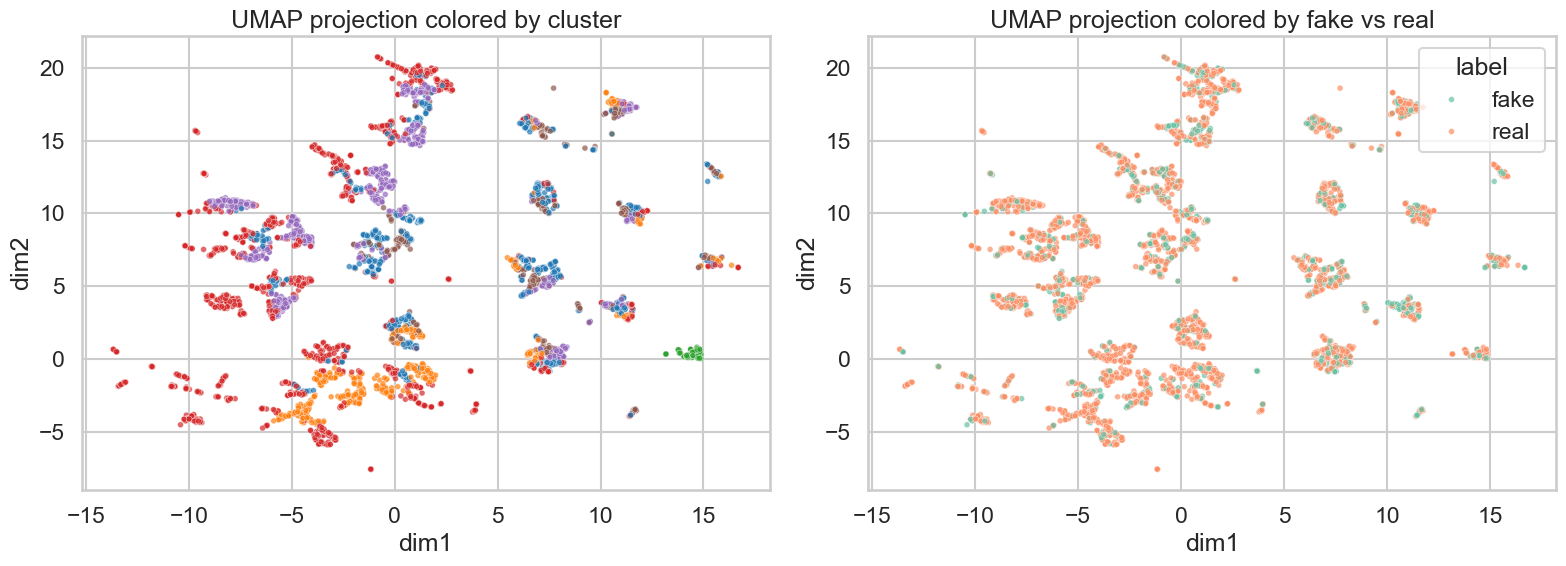

In [18]:
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    reduced = reducer.fit_transform(X_combined)
    reducer_name = "UMAP"
else:
    reducer = PCA(n_components=2, random_state=RANDOM_STATE)
    reduced = reducer.fit_transform(X_combined)
    reducer_name = "PCA"

df["dim1"] = reduced[:, 0]
df["dim2"] = reduced[:, 1]

plot_df = df.sample(min(5000, len(df)), random_state=RANDOM_STATE).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=plot_df, x="dim1", y="dim2", hue="cluster", palette="tab10", s=18, alpha=0.7, ax=axes[0], legend=False)
axes[0].set_title(f"{reducer_name} projection colored by cluster")

sns.scatterplot(data=plot_df, x="dim1", y="dim2", hue="label", palette="Set2", s=18, alpha=0.7, ax=axes[1])
axes[1].set_title(f"{reducer_name} projection colored by fake vs real")

plt.tight_layout()
plt.show()


### Results: Cluster Summary

KMeans (k=6) discovered six distinct headline clusters. Sorted by mean log tweet count (virality proxy):

| Cluster | Size | Fake Rate | Mean Tweets | Central | Peripheral | Neutral |
|---------|------|-----------|-------------|---------|------------|--------|
| 3 | 8,107 | 23.8% | **133.8** | 0.046 | 0.037 | 0.433 |
| 1 | 3,066 | 15.5% | 81.1 | 0.072 | 0.080 | 0.303 |
| 2 | 406 | 26.1% | 59.7 | 0.092 | **0.199** | 0.385 |
| 4 | 4,904 | 25.1% | 60.3 | 0.066 | 0.108 | 0.351 |
| 0 | 4,572 | 29.5% | 59.9 | 0.126 | 0.053 | 0.438 |
| 5 | 2,141 | **31.2%** | 64.0 | **0.189** | 0.106 | 0.352 |

Key findings:

- **All clusters are labelled neutral-like** because `neutral_score` consistently exceeds both central and peripheral scores. Short headlines are structurally sparse and rarely display overt emotional markers.
- **Cluster 3 is the most viral** (mean 133.8 tweets) and has the lowest structural complexity so simple, declarative, factual-sounding headlines spread most widely.
- **Clusters 0 and 5 have the highest fake rates** (29.5% and 31.2%) and the highest central scores so longer, structurally complex headlines appear disproportionately in fake news, possibly because fabricated stories require more elaborate framing.
- **Cluster 2** is smallest but has the highest peripheral score (0.199) so likely emotionally loaded gossip headlines with question framing.
- The **fake rate does not monotonically correlate with virality** so the most viral cluster (3) has a lower fake rate than less viral clusters, challenging the naive assumption that viral = fake.


## 8. Popularity Analysis

This section asks:

- which clusters are most viral?
- which persuasion styles dominate highly shared content?
- what features are present in **more popular fake misinformation**?


### Results: Representative Headlines per Cluster

Centroid-nearest examples reveal thematic and stylistic character:

- **Cluster 0**: Mixed celebrity/political headlines of moderate length and low sentiment (e.g., "Melania Trump Hired Exorcist To Cleanse White House").
- **Cluster 1**: Entertainment award/event headlines with descriptive, factual tone ("ESPY Awards", "Cannes Film Festival").
- **Cluster 2**: Question-format clickbait with high peripheral score due to rhetorical question structure ("Fixer Upper Is Ending. What Is Chip and Joanna Gaines...?").
- **Cluster 3**: Short celebrity news snippets with high virality ("Jason Momoa, Lisa Bonet Officially Marry"). Compact, factual, most widely shared.
- **Cluster 4**: Named-entity-dense headlines mentioning specific celebrities with emotional context ("Matt Bomer Really Proud of Wentworth Miller...").
- **Cluster 5**: Quote-attribution headlines with embedded clauses ("Alec Baldwin Admits He's Bullied Women..."). Longest headlines, highest central score due to reporting verb + dependent clause structure.


,articles,viral_rate,mean_tweet_count,median_tweet_count,mean_central,mean_peripheral,mean_neutral
cluster,,,,,,,
3,8107,0.130381,133.760824,41.0,0.045996,0.037333,0.433308
1,3066,0.107632,81.082518,42.0,0.072346,0.079879,0.303161
5,2141,0.074731,64.018683,28.0,0.188653,0.106228,0.352462
4,4904,0.079323,60.257137,37.0,0.065955,0.108182,0.351322
0,4572,0.081146,59.854331,32.0,0.126269,0.052616,0.437532
2,406,0.071429,59.667488,34.0,0.091781,0.198857,0.384832


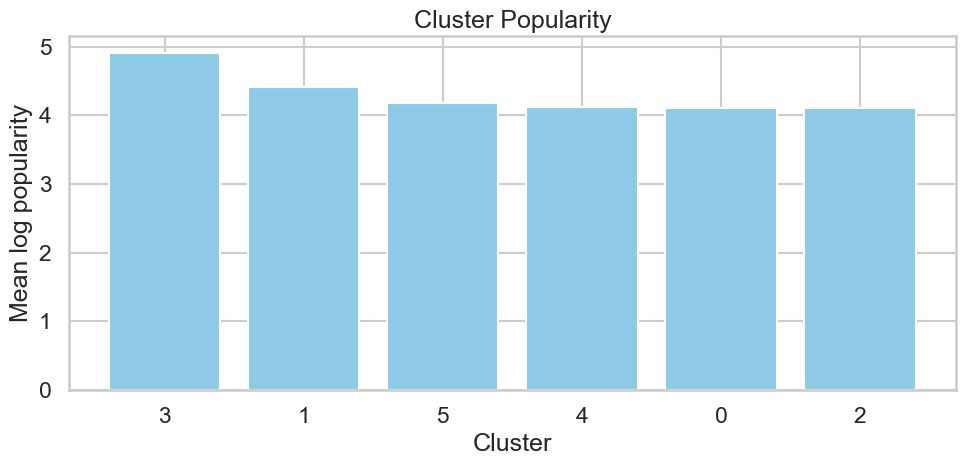

In [19]:
cluster_popularity = (
    df.groupby("cluster")
    .agg(
        articles=("cluster", "size"),
        viral_rate=("viral_flag", "mean"),
        mean_tweet_count=("tweet_count", "mean"),
        median_tweet_count=("tweet_count", "median"),
        mean_central=("central_score", "mean"),
        mean_peripheral=("peripheral_score", "mean"),
        mean_neutral=("neutral_score", "mean"),
    )
    .sort_values("mean_tweet_count", ascending=False)
)
display(cluster_popularity)

plt.figure(figsize=(10, 5))
plt.bar(cluster_popularity.index.astype(str), cluster_popularity["mean_log_tweet_count"] if "mean_log_tweet_count" in cluster_popularity.columns else np.log1p(cluster_popularity["mean_tweet_count"]), color="#8ecae6")
plt.title("Cluster Popularity")
plt.xlabel("Cluster")
plt.ylabel("Mean log popularity")
plt.tight_layout()
plt.show()


In [20]:
top_1_threshold = df["tweet_count"].quantile(0.99)
top_1_df = df[df["tweet_count"] >= top_1_threshold].copy()

print(f"Top 1% threshold: {top_1_threshold:,.0f}")
print("\nTop 1% cluster distribution:")
display(top_1_df["cluster"].value_counts(normalize=True).rename("proportion").to_frame())

print("\nTop 1% style distribution:")
style_map = cluster_summary["style_label"].to_dict()
top_1_df["cluster_style"] = top_1_df["cluster"].map(style_map)
display(top_1_df["cluster_style"].value_counts(normalize=True).rename("proportion").to_frame())


Top 1% threshold: 1,020

Top 1% cluster distribution:


,proportion
cluster,
3,0.684543
1,0.107256
4,0.085174
0,0.085174
5,0.025237
2,0.012618



Top 1% style distribution:


,proportion
cluster_style,
neutral_like,1.0


### 8.1 Which Features Are Present in More Popular Fake Misinformation?

This is the dedicated fake-misinformation section.

We isolate the **fake** headlines, define a `popular_fake_flag` as the top 10% within the fake subset, and compare their feature profile to the rest of fake content.


,popular_fake_mean,rest_fake_mean,difference
tweet_count,1023.742215,33.209967,990.532247
numbers_per_token,0.022329,0.013788,0.008541
neutral_score,0.401447,0.398752,0.002694
uppercase_word_count,0.000000,0.000000,0.000000
central_x_peripheral,0.004473,0.007428,-0.002955
peripheral_score,0.054479,0.077799,-0.023320
punctuation_density,0.081782,0.106469,-0.024688
central_score,0.062221,0.090253,-0.028032
exclamation_count,0.041522,0.074367,-0.032845
advcl_count,0.058824,0.112613,-0.053790


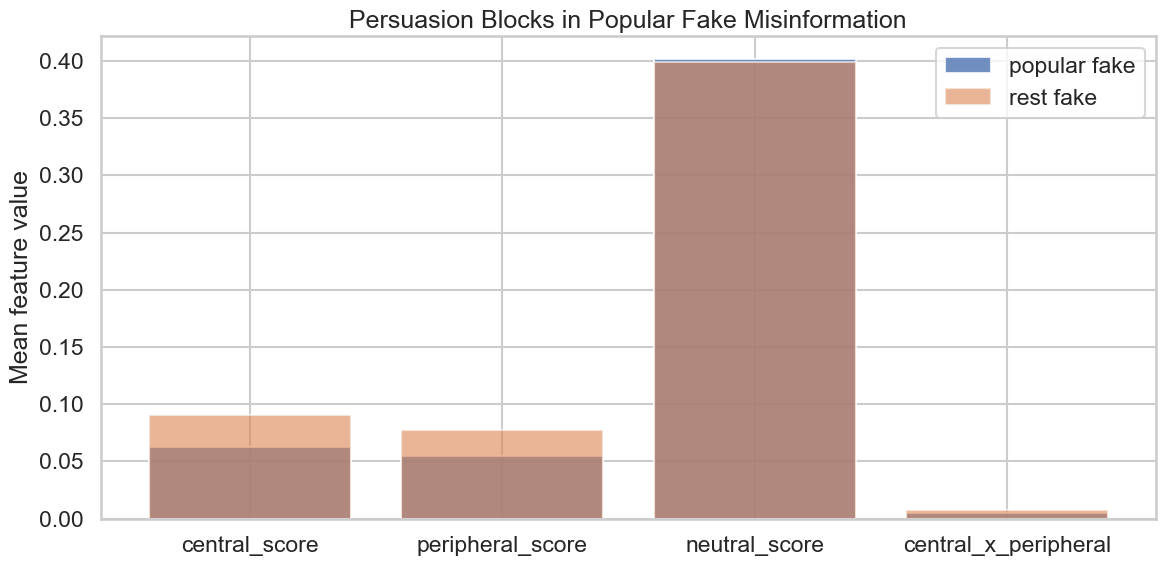

,feature,u_statistic,p_value
3,central_x_peripheral,934354.0,9.428233e-50
0,central_score,972934.0,2.089201e-43
1,peripheral_score,1039096.5,1.560970e-33
2,neutral_score,1539632.0,2.497459e-01


In [21]:
fake_df = df[df["label"] == "fake"].copy()
popular_fake_threshold = fake_df["tweet_count"].quantile(0.90)
fake_df["popular_fake_flag"] = (fake_df["tweet_count"] >= popular_fake_threshold).astype(int)

popular_fake = fake_df[fake_df["popular_fake_flag"] == 1].copy()
rest_fake = fake_df[fake_df["popular_fake_flag"] == 0].copy()

fake_compare_cols = [
    "central_score",
    "peripheral_score",
    "neutral_score",
    "sentiment_magnitude",
    "entity_count",
    "numbers_per_token",
    "parse_depth",
    "subordinate_clause_count",
    "advcl_count",
    "ccomp_xcomp_count",
    "exclamation_count",
    "question_count",
    "uppercase_word_count",
    "punctuation_density",
    "central_x_peripheral",
    "tweet_count",
]

fake_feature_compare = pd.DataFrame(
    {
        "popular_fake_mean": popular_fake[fake_compare_cols].mean(),
        "rest_fake_mean": rest_fake[fake_compare_cols].mean(),
    }
)
fake_feature_compare["difference"] = fake_feature_compare["popular_fake_mean"] - fake_feature_compare["rest_fake_mean"]
display(fake_feature_compare.sort_values("difference", ascending=False))

plt.figure(figsize=(12, 6))
focus = fake_feature_compare.loc[["central_score", "peripheral_score", "neutral_score", "central_x_peripheral"], :]
plt.bar(focus.index, focus["popular_fake_mean"], alpha=0.8, label="popular fake")
plt.bar(focus.index, focus["rest_fake_mean"], alpha=0.6, label="rest fake")
plt.title("Persuasion Blocks in Popular Fake Misinformation")
plt.ylabel("Mean feature value")
plt.legend()
plt.tight_layout()
plt.show()

if mannwhitneyu is not None:
    stat_rows = []
    for feature in ["central_score", "peripheral_score", "neutral_score", "central_x_peripheral"]:
        stat, p_value = mannwhitneyu(popular_fake[feature], rest_fake[feature], alternative="two-sided")
        stat_rows.append({"feature": feature, "u_statistic": stat, "p_value": p_value})
    display(pd.DataFrame(stat_rows).sort_values("p_value"))


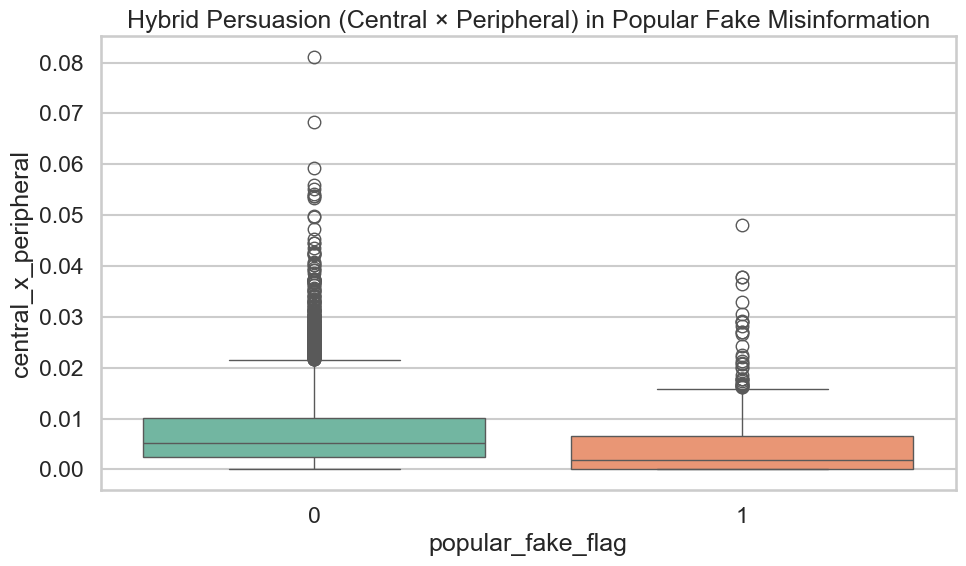

central_score: Spearman rho=-0.1292, p=7.477e-23
peripheral_score: Spearman rho=-0.1103, p=4.713e-17
neutral_score: Spearman rho=0.0041, p=0.7562
central_x_peripheral: Spearman rho=-0.1361, p=3.451e-25


In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=fake_df, x="popular_fake_flag", y="central_x_peripheral", palette="Set2")
plt.title("Hybrid Persuasion (Central × Peripheral) in Popular Fake Misinformation")
plt.xlabel("popular_fake_flag")
plt.ylabel("central_x_peripheral")
plt.tight_layout()
plt.show()

if spearmanr is not None:
    for feature in ["central_score", "peripheral_score", "neutral_score", "central_x_peripheral"]:
        rho, p_value = spearmanr(fake_df[feature], fake_df["log_tweet_count"])
        print(f"{feature}: Spearman rho={rho:.4f}, p={p_value:.4g}")


## 9. Classification System for Popular Fake Misinformation

We now build a classifier that identifies **popular fake misinformation** using the advanced feature space.

Target:

- `popular_fake_flag` within the fake-news subset

Inputs:

- structural features
- stylistic features
- continuous persuasion scores
- interaction features
- SBERT embeddings


In [23]:
fake_indices = fake_df.index.to_numpy()
fake_handcrafted = handcrafted_features.loc[fake_indices].reset_index(drop=True)
fake_handcrafted_scaled = StandardScaler().fit_transform(fake_handcrafted)
fake_embeddings = embeddings[fake_indices]
X_fake_combined = np.hstack([fake_handcrafted_scaled, fake_embeddings])
y_fake_popular = fake_df["popular_fake_flag"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_fake_combined,
    y_fake_popular,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_fake_popular,
)

booster_name = None
booster_model = None

try:
    from xgboost import XGBClassifier

    booster_name = "xgboost"
    booster_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )
except Exception:
    try:
        from lightgbm import LGBMClassifier

        booster_name = "lightgbm"
        booster_model = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=RANDOM_STATE,
        )
    except Exception:
        booster_name = "logistic_fallback"
        booster_model = LogisticRegression(max_iter=4000, random_state=RANDOM_STATE)

booster_model.fit(X_train, y_train)
y_pred = booster_model.predict(X_test)
y_proba = booster_model.predict_proba(X_test)[:, 1] if hasattr(booster_model, "predict_proba") else None

metrics = {
    "model": booster_name,
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
}
if y_proba is not None:
    metrics["roc_auc"] = roc_auc_score(y_test, y_proba)

display(pd.Series(metrics).to_frame("value"))
print(classification_report(y_test, y_pred, digits=3))


,value
model,xgboost
accuracy,0.926338
f1,0.480392
roc_auc,0.809167


              precision    recall  f1-score   support

           0      0.930     0.992     0.960      1294
           1      0.831     0.338     0.480       145

    accuracy                          0.926      1439
   macro avg      0.880     0.665     0.720      1439
weighted avg      0.920     0.926     0.912      1439



,feature,coefficient,abs_coefficient
0,central_score,-1.100558,1.100558
12,central_x_peripheral,0.916141,0.916141
1,peripheral_score,-0.577431,0.577431
6,parse_depth,-0.522495,0.522495
7,subordinate_clause_count,0.421236,0.421236
9,question_count,-0.272499,0.272499
3,sentiment_magnitude,-0.257027,0.257027
2,neutral_score,-0.235415,0.235415
5,numbers_per_token,0.190628,0.190628
4,entity_count,-0.166906,0.166906


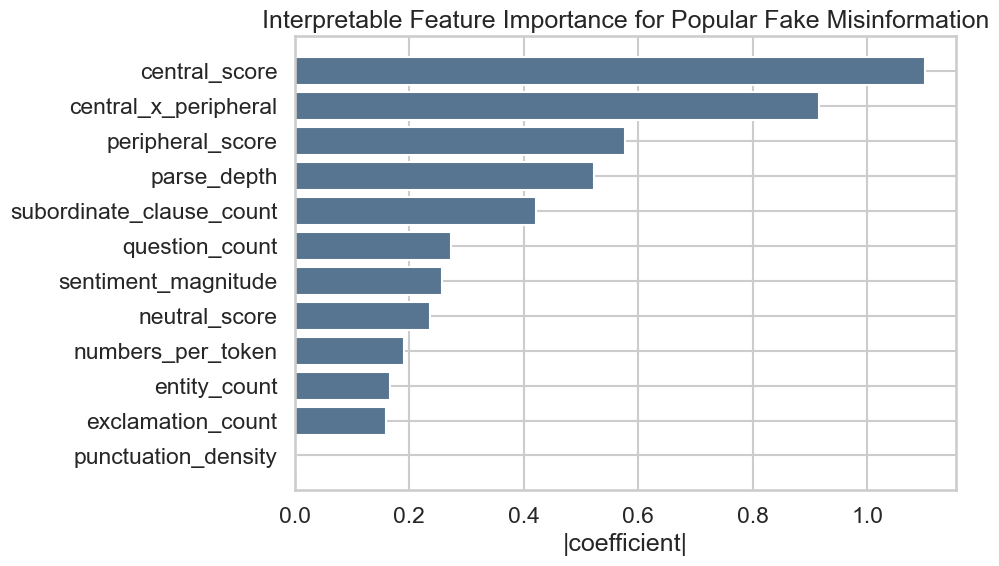

In [24]:
interpretable_X = fake_df[
    [
        "central_score",
        "peripheral_score",
        "neutral_score",
        "sentiment_magnitude",
        "entity_count",
        "numbers_per_token",
        "parse_depth",
        "subordinate_clause_count",
        "exclamation_count",
        "question_count",
        "uppercase_word_count",
        "punctuation_density",
        "central_x_peripheral",
    ]
].copy()
interpretable_y = fake_df["popular_fake_flag"].copy()

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    interpretable_X,
    interpretable_y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=interpretable_y,
)

interpretable_model = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
interpretable_model.fit(StandardScaler().fit_transform(Xi_train), yi_train)

coef_df = pd.DataFrame(
    {
        "feature": interpretable_X.columns,
        "coefficient": interpretable_model.coef_[0],
        "abs_coefficient": np.abs(interpretable_model.coef_[0]),
    }
).sort_values("abs_coefficient", ascending=False)
display(coef_df)

plt.figure(figsize=(10, 6))
plt.barh(coef_df["feature"].head(12)[::-1], coef_df["abs_coefficient"].head(12)[::-1], color="#577590")
plt.title("Interpretable Feature Importance for Popular Fake Misinformation")
plt.xlabel("|coefficient|")
plt.tight_layout()
plt.show()


## 10. Interpretation

The next cell summarizes the discovered persuasion patterns and their relationship to virality.


In [26]:
cluster_style_map = cluster_summary["style_label"].to_dict()
df["cluster_style"] = df["cluster"].map(cluster_style_map)

popular_fake_feature = fake_feature_compare["difference"].sort_values(ascending=False).index[0]
top_cluster = cluster_popularity.index[0]
top_cluster_style = cluster_style_map.get(top_cluster, "unknown")


## 11. Limitations

Important limitations include:

- `tweet_count` is not the same as belief, endorsement, or persuasion success
- cluster labels are discovered patterns, not ground-truth rhetorical annotations
- short headlines remain semantically implicit, so some persuasion mechanisms are still missed
- spaCy parsing and named entity recognition are imperfect on noisy headlines
- SBERT captures meaning effectively, but the clusters remain interpretive rather than definitive

Even so, this notebook provides a substantially richer picture of persuasion patterns than simple keyword-only analysis.
